In [78]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch as tr


DATA_PATH = Path(
    "/home/gkulemeyer/Documents/Repos/RNADiffusion/"
    "logs/ArchiveII_famfold/srp/t2/seed42"
)

SEQ_FILE = "srp_Acin.baum._CP000521.pt"
NUM_SAMPLES_TO_PLOT = 3

eval_dir = DATA_PATH / "eval/best"


def get_threshold(path):
    return float(path.name.removeprefix("samples_thr"))


def get_raw_samples(data):
    # Compatibilidad con archivos anteriores
    return data["raw_samples"] if "raw_samples" in data else data["samples"]


def count_bp(matrix):
    return int(tr.triu(matrix, diagonal=1).sum().item())

In [79]:
# Descubrir y ordenar carpetas por threshold
sample_dirs = sorted( eval_dir.glob("samples_thr*"), key=get_threshold)

if not sample_dirs:
    raise ValueError(f"No threshold directories found in {eval_dir}")

data_by_threshold = {
    get_threshold(directory): tr.load(
        directory / SEQ_FILE,
        map_location="cpu",
    )
    for directory in sample_dirs
}

thresholds = list(data_by_threshold)
reference = data_by_threshold[thresholds[0]]

length = int(reference["length"])
target = reference["target"]

if target.ndim == 3:
    target = target.argmax(dim=0)

target = target[:length, :length]

raw_reference = get_raw_samples(reference)[..., :length, :length]

num_samples = min(
    NUM_SAMPLES_TO_PLOT,
    raw_reference.shape[0],
)

print("Sequence:", SEQ_FILE)
print("Length:", length)
print("Thresholds:", thresholds)
print("Number of samples:", raw_reference.shape[0])

raw_are_equal = all(
    tr.equal(
        raw_reference,
        get_raw_samples(data)[..., :length, :length],
    )
    for data in data_by_threshold.values()
)

seeds_are_equal = all(
    data.get("sample_seeds", data.get("seeds"))
    == reference.get("sample_seeds", reference.get("seeds"))
    for data in data_by_threshold.values()
)

print("Same raw samples across thresholds:", raw_are_equal)
print("Same seeds across thresholds:", seeds_are_equal)

Sequence: srp_Acin.baum._CP000521.pt
Length: 104
Thresholds: [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
Number of samples: 16
Same raw samples across thresholds: True
Same seeds across thresholds: True


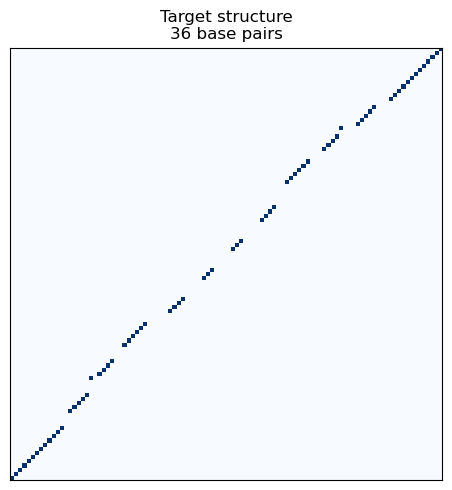

In [80]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(
    target,
    cmap="Blues",
    vmin=0,
    vmax=1,
    interpolation="nearest",
)

ax.set_title(f"Target structure\n{count_bp(target)} base pairs")
ax.set_xticks([])
ax.set_yticks([])

fig.tight_layout()
plt.show()

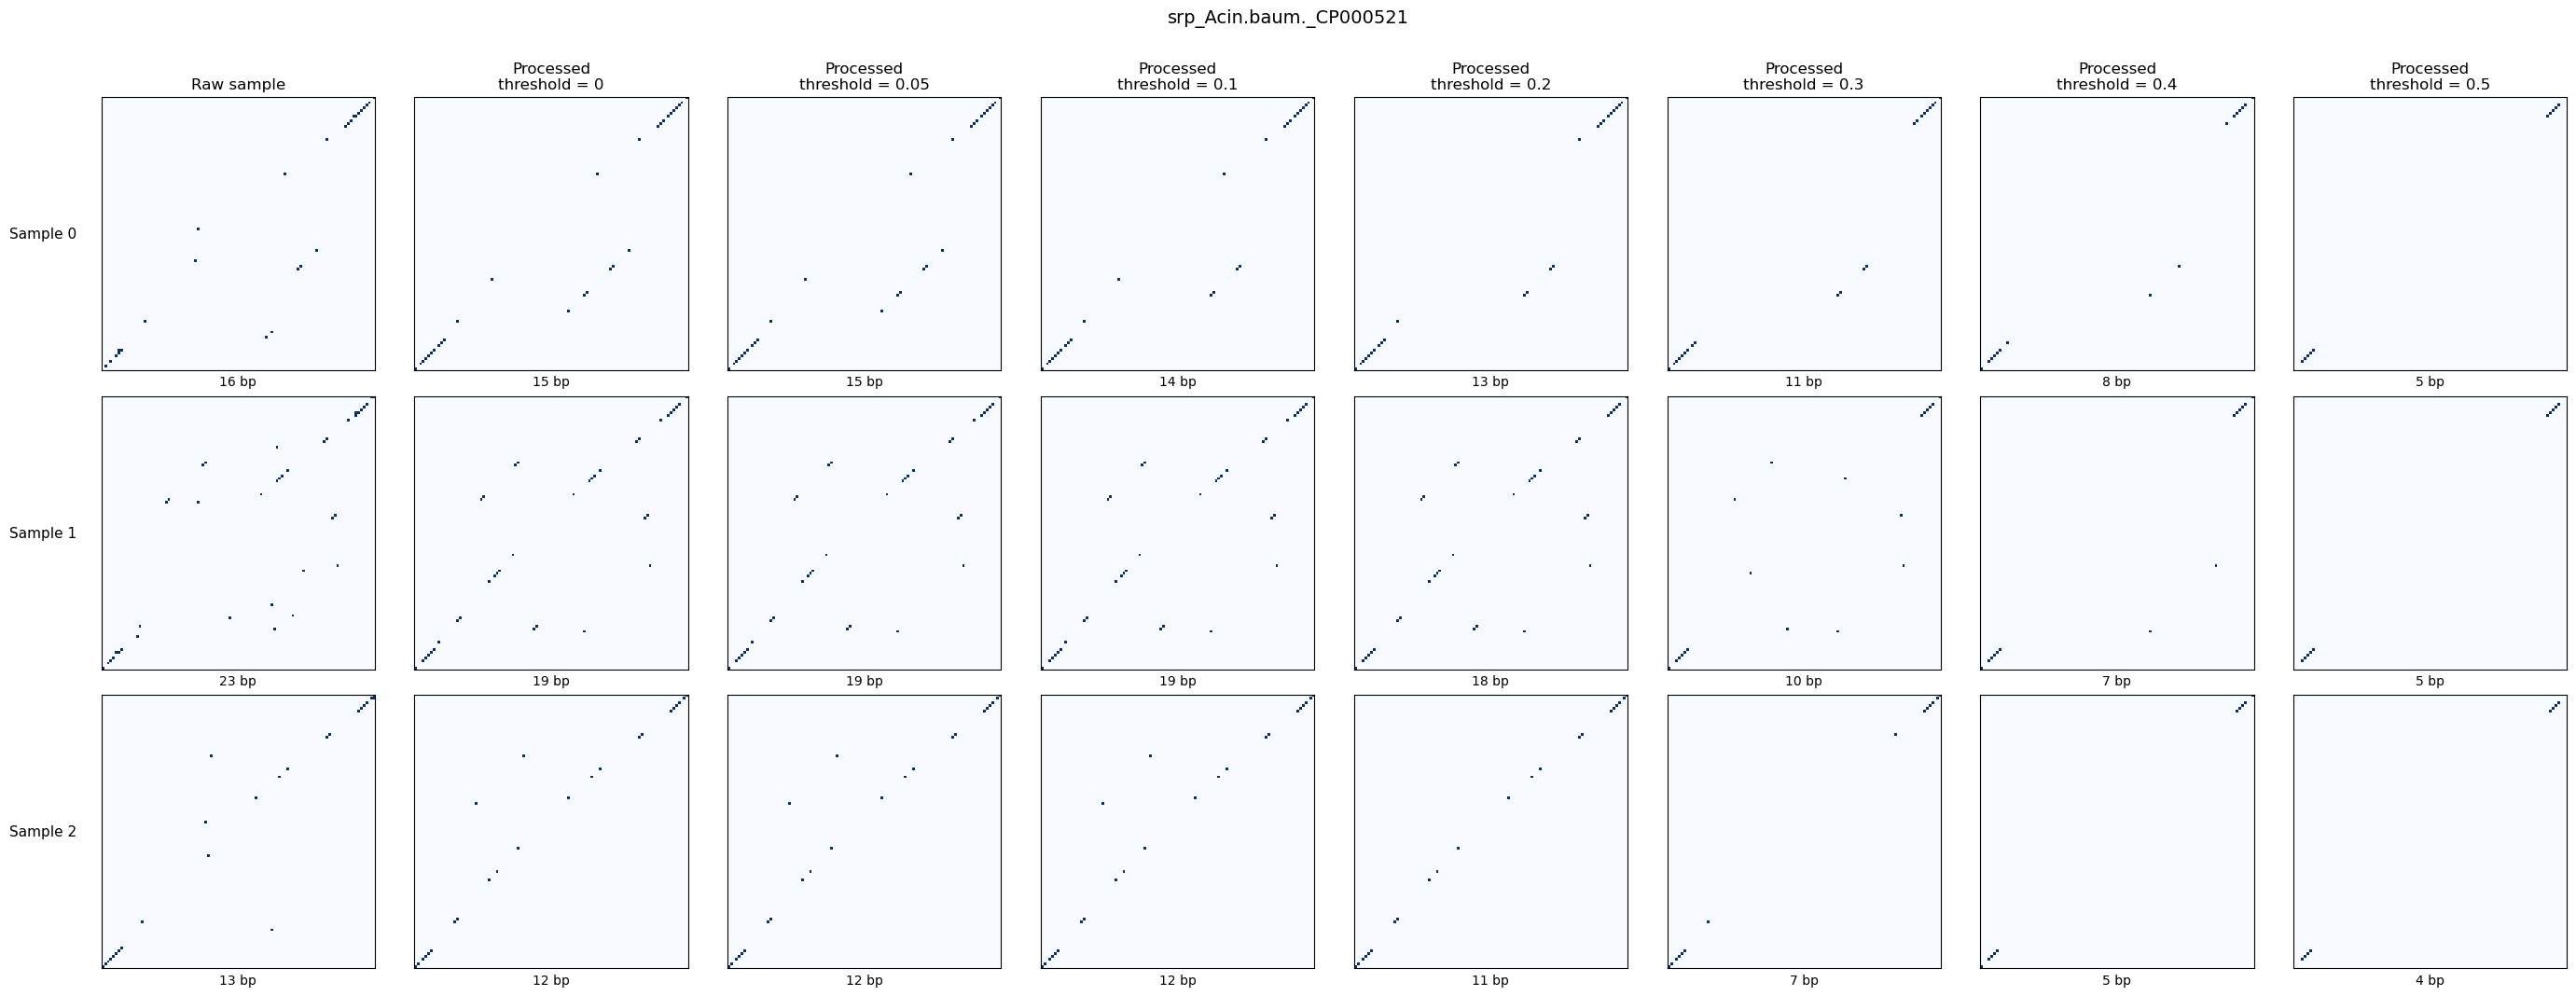

In [81]:
ncols = 1 + len(thresholds)

fig, axes = plt.subplots(
    num_samples,
    ncols,
    figsize=(3.5 * ncols, 3.5 * num_samples),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for sample_id in range(num_samples):
    raw_sample = raw_reference[sample_id]

    ax = axes[sample_id, 0]
    ax.imshow(
        raw_sample,
        cmap="Blues",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_ylabel(
        f"Sample {sample_id}",
        fontsize=11,
        rotation=0,
        labelpad=45,
        va="center",
    )
    ax.set_xlabel(f"{count_bp(raw_sample)} bp")

    if sample_id == 0:
        ax.set_title("Raw sample")

    for column, threshold in enumerate(thresholds, start=1):
        processed_sample = data_by_threshold[
            threshold
        ]["processed_samples"][sample_id, :length, :length]

        ax = axes[sample_id, column]
        ax.imshow(
            processed_sample,
            cmap="Blues",
            vmin=0,
            vmax=1,
            interpolation="nearest",
        )
        ax.set_xlabel(f"{count_bp(processed_sample)} bp")

        if sample_id == 0:
            ax.set_title(f"Processed\nthreshold = {threshold:g}")

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

fig.suptitle(
    SEQ_FILE.removesuffix(".pt"),
    fontsize=14,
    y=1.01,
)

fig.tight_layout()
plt.show()

In [82]:
rows = []

for sample_id in range(num_samples):
    raw_sample = raw_reference[sample_id]

    for threshold, data in data_by_threshold.items():
        processed_sample = data[
            "processed_samples"
        ][sample_id, :length, :length]

        rows.append({
            "sample_id": sample_id,
            "threshold": threshold,
            "raw_bp": count_bp(raw_sample),
            "processed_bp": count_bp(processed_sample),
            "removed_bp": (
                count_bp(raw_sample)
                - count_bp(processed_sample)
            ),
        })

comparison = pd.DataFrame(rows)
comparison

,sample_id,threshold,raw_bp,processed_bp,removed_bp
0,0,0.00,16,15,1
1,0,0.05,16,15,1
2,0,0.10,16,14,2
3,0,0.20,16,13,3
4,0,0.30,16,11,5
5,0,0.40,16,8,8
6,0,0.50,16,5,11
7,1,0.00,23,19,4
8,1,0.05,23,19,4
9,1,0.10,23,19,4


In [83]:
import re

import matplotlib.pyplot as plt
import pandas as pd


def threshold_from_stats_path(path):
    match = re.search(r"thr(\d+)_stats$", path.stem)

    if match is None:
        raise ValueError(f"Cannot extract threshold from {path.name}")

    code = match.group(1)

    # thr01 -> 0.1, thr08 -> 0.8, thr10 -> 1.0
    return float(f"{code[0]}.{code[1:] or '0'}")


stats_paths = sorted(
    eval_dir.glob(
        "samples_stats*/"
        "processed_ensemble_metrics_thr*_stats.csv"
    ),
    key=threshold_from_stats_path,
)

if not stats_paths:
    raise ValueError(f"No processed stats files found in {eval_dir}")

processed_stats = pd.concat(
    [
        pd.read_csv(path).assign(
            threshold=threshold_from_stats_path(path)
        )
        for path in stats_paths
    ],
    ignore_index=True,
)

processed_stats = processed_stats.sort_values(
    ["threshold", "consensus"]
).reset_index(drop=True)

print("Loaded files:")

for path in stats_paths:
    print(
        f"  threshold={threshold_from_stats_path(path):g}: "
        f"{path.relative_to(eval_dir)}"
    )

processed_stats

Loaded files:
  threshold=0: samples_stats00/processed_ensemble_metrics_thr00_stats.csv
  threshold=0.05: samples_stats005/processed_ensemble_metrics_thr005_stats.csv
  threshold=0.1: samples_stats01/processed_ensemble_metrics_thr01_stats.csv
  threshold=0.2: samples_stats02/processed_ensemble_metrics_thr02_stats.csv
  threshold=0.3: samples_stats03/processed_ensemble_metrics_thr03_stats.csv
  threshold=0.4: samples_stats04/processed_ensemble_metrics_thr04_stats.csv
  threshold=0.5: samples_stats05/processed_ensemble_metrics_thr05_stats.csv


,consensus,mean,std,std_mean,std_std,best,worst,threshold
0,1,0.168936,0.150565,0.029284,0.024849,0.203194,0.135590,0.00
1,3,0.162729,0.165313,0.020494,0.018842,0.187044,0.139947,0.00
2,5,0.160554,0.168255,0.016647,0.018006,0.179932,0.141696,0.00
3,7,0.158725,0.171009,0.013512,0.015365,0.174392,0.143671,0.00
4,1,0.170029,0.150877,0.029385,0.024940,0.204381,0.136526,0.05
5,3,0.162735,0.165321,0.020488,0.018839,0.187045,0.139961,0.05
6,5,0.160554,0.168255,0.016647,0.018006,0.179932,0.141696,0.05
7,7,0.158725,0.171009,0.013512,0.015365,0.174392,0.143671,0.05
8,1,0.171809,0.152120,0.029692,0.025195,0.206382,0.137772,0.10
9,3,0.162732,0.165324,0.020440,0.018824,0.186978,0.139974,0.10


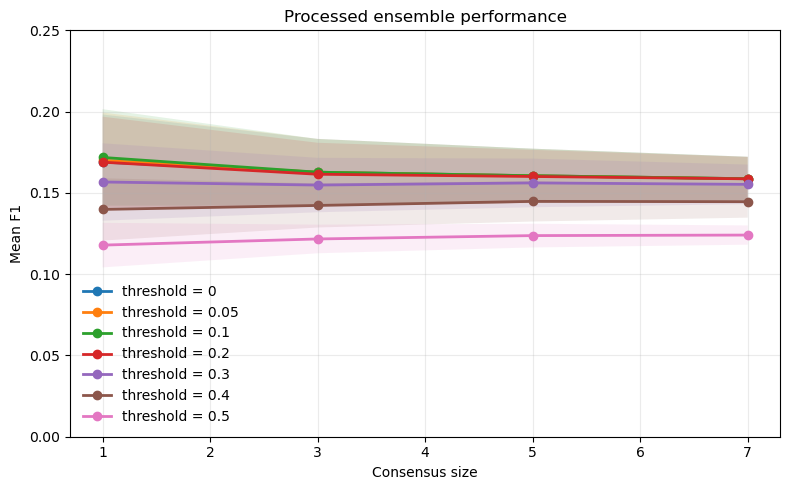

In [84]:
fig, ax = plt.subplots(figsize=(8, 5))

for threshold, threshold_stats in processed_stats.groupby("threshold"):
    x = threshold_stats["consensus"].to_numpy()
    mean = threshold_stats["mean"].to_numpy()
    trial_std = threshold_stats["std_mean"].to_numpy()

    ax.plot(
        x,
        mean,
        marker="o",
        linewidth=2,
        label=f"threshold = {threshold:g}",
    )

    ax.fill_between(
        x,
        mean - trial_std,
        mean + trial_std,
        alpha=0.12,
    )

ax.set(
    xlabel="Consensus size",
    ylabel="Mean F1",
    title="Processed ensemble performance",
)

ax.set_ylim(0, 0.25)
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

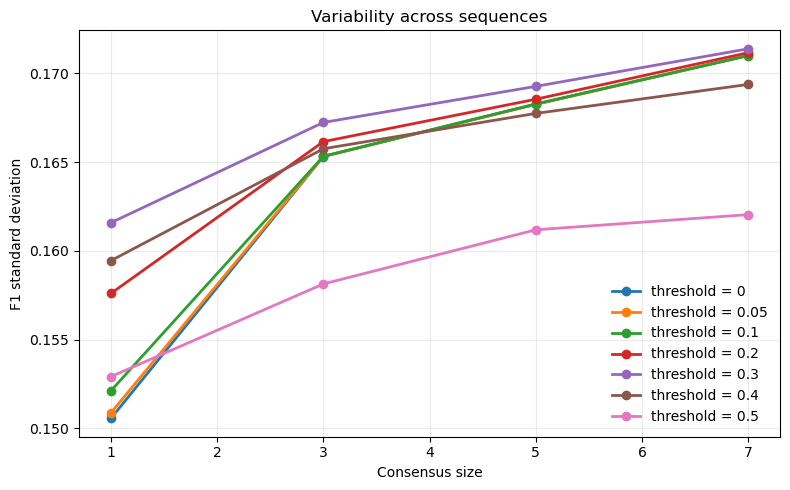

In [85]:
fig, ax = plt.subplots(figsize=(8, 5))

for threshold, threshold_stats in processed_stats.groupby("threshold"):
    ax.plot(
        threshold_stats["consensus"],
        threshold_stats["std"],
        marker="o",
        linewidth=2,
        label=f"threshold = {threshold:g}",
    )

ax.set(
    xlabel="Consensus size",
    ylabel="F1 standard deviation",
    title="Variability across sequences",
)

ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [86]:
f1_table = processed_stats.pivot(
    index="consensus",
    columns="threshold",
    values="mean",
)

f1_table.columns = [
    f"threshold_{threshold:g}"
    for threshold in f1_table.columns
]

f1_table

,threshold_0,threshold_0.05,threshold_0.1,threshold_0.2,threshold_0.3,threshold_0.4,threshold_0.5
consensus,,,,,,,
1,0.168936,0.170029,0.171809,0.168895,0.156699,0.139833,0.117872
3,0.162729,0.162735,0.162732,0.161468,0.154823,0.142268,0.121659
5,0.160554,0.160554,0.160558,0.160098,0.156141,0.144784,0.123727
7,0.158725,0.158725,0.158698,0.158647,0.155236,0.144581,0.124052


In [87]:
best_by_threshold = (
    processed_stats.loc[
        processed_stats
        .groupby("threshold")["mean"]
        .idxmax(),
        [
            "threshold",
            "consensus",
            "mean",
            "std",
            "std_mean",
        ],
    ]
    .sort_values("threshold")
    .reset_index(drop=True)
)

best_by_threshold

,threshold,consensus,mean,std,std_mean
0,0.00,1,0.168936,0.150565,0.029284
1,0.05,1,0.170029,0.150877,0.029385
2,0.10,1,0.171809,0.152120,0.029692
3,0.20,1,0.168895,0.157603,0.027993
4,0.30,1,0.156699,0.161585,0.023820
5,0.40,5,0.144784,0.167741,0.012386
6,0.50,7,0.124052,0.162038,0.005915


In [88]:
RAW_STATS_PATH = eval_dir / "raw_ensemble_stats.csv"

raw_stats = (
    pd.read_csv(RAW_STATS_PATH)
    .sort_values("consensus")
    .reset_index(drop=True)
)

print(f"Raw stats: {RAW_STATS_PATH.relative_to(eval_dir)}")
raw_stats

Raw stats: raw_ensemble_stats.csv


,consensus,mean,std,std_mean,std_std,best,worst
0,1,0.167910,0.144518,0.029007,0.023995,0.201879,0.134484
1,3,0.167596,0.162791,0.021457,0.019020,0.193130,0.143626
2,5,0.165102,0.166397,0.017748,0.017724,0.185695,0.144886
3,7,0.162797,0.169978,0.014394,0.015237,0.179603,0.146768


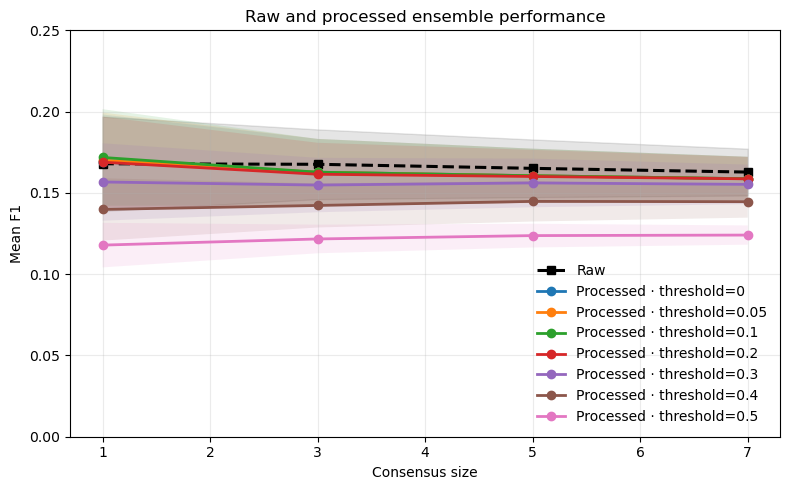

In [89]:
fig, ax = plt.subplots(figsize=(8, 5))

# Raw ensemble
x = raw_stats["consensus"].to_numpy()
mean = raw_stats["mean"].to_numpy()
trial_std = raw_stats["std_mean"].to_numpy()

ax.plot(
    x,
    mean,
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2.2,
    label="Raw",
)

ax.fill_between(
    x,
    mean - trial_std,
    mean + trial_std,
    color="black",
    alpha=0.10,
)

# Processed ensembles
for threshold, threshold_stats in processed_stats.groupby("threshold"):
    x = threshold_stats["consensus"].to_numpy()
    mean = threshold_stats["mean"].to_numpy()
    trial_std = threshold_stats["std_mean"].to_numpy()

    ax.plot(
        x,
        mean,
        marker="o",
        linewidth=2,
        label=f"Processed · threshold={threshold:g}",
    )

    ax.fill_between(
        x,
        mean - trial_std,
        mean + trial_std,
        alpha=0.12,
    )

ax.set(
    xlabel="Consensus size",
    ylabel="Mean F1",
    title="Raw and processed ensemble performance",
)

ax.set_ylim(0, 0.25)
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [90]:
raw_table = (
    raw_stats
    .set_index("consensus")["mean"]
    .rename("raw")
)

processed_table = processed_stats.pivot(
    index="consensus",
    columns="threshold",
    values="mean",
)

processed_table.columns = [
    f"processed_thr{threshold:g}"
    for threshold in processed_table.columns
]

f1_comparison = pd.concat(
    [raw_table, processed_table],
    axis=1,
)

f1_comparison

,raw,processed_thr0,processed_thr0.05,processed_thr0.1,processed_thr0.2,processed_thr0.3,processed_thr0.4,processed_thr0.5
consensus,,,,,,,,
1,0.167910,0.168936,0.170029,0.171809,0.168895,0.156699,0.139833,0.117872
3,0.167596,0.162729,0.162735,0.162732,0.161468,0.154823,0.142268,0.121659
5,0.165102,0.160554,0.160554,0.160558,0.160098,0.156141,0.144784,0.123727
7,0.162797,0.158725,0.158725,0.158698,0.158647,0.155236,0.144581,0.124052


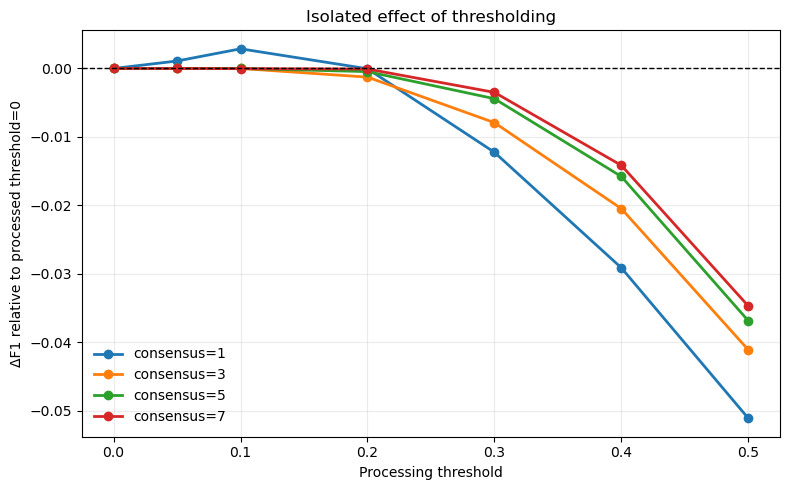

In [92]:
threshold_effect = processed_table.sub(
    processed_table["processed_thr0"],
    axis=0,
)

fig, ax = plt.subplots(figsize=(8, 5))

for consensus in threshold_effect.index:
    values = threshold_effect.loc[consensus]

    thresholds = [
        float(column.removeprefix("processed_thr"))
        for column in values.index
    ]

    ax.plot(
        thresholds,
        values,
        marker="o",
        linewidth=2,
        label=f"consensus={consensus}",
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set(
    xlabel="Processing threshold",
    ylabel="ΔF1 relative to processed threshold=0",
    title="Isolated effect of thresholding",
)

ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()